# How do we make a wavelength calibration?

This notebook details how to establish a wavelength calibration for a spectrum image, building on the skills of [measuring line diagnostics](lines.ipynb). Here, we'll work with an extracted HeNeAr emission line spectrum from the SBO 24" spectrograph, tying many emission lines together into a coherent model for the relationship between pixel and wavelength. 

## Start with a Reference List of Wavelengths

For a wavelength calibration, we need to know the actual wavelengths of the lines we're looking at. Here are a few resources that might help, both as quantitative datasets that can be read into tables of lines and as qualitative visual references to determine which line is which.

### Quantitative Lists of Wavelengths

To avoid having to type in lots of individual wavelengths, you may want a list of wavelengths you can read into Python arrays. Here are a few:

- [HeNeAr lines at SBO](data/HeNeAr-wavelengths-sbo.ecsv) = a list of lines culled from an ancient printed wavelength-calibration manual for the SBO 24" spectrograph. These have the advantage that they are all probably lines that have been observed at least once from SBO.
- [a whole bunch of random lists of lines](https://github.com/jradavenport/pykosmos/tree/main/pykosmos/resources/linelists) = a directory hidden inside the repository for [PyKOSMOS](https://github.com/jradavenport/pykosmos/) that had oodles of different lists of lines. Many come from the historical guts of [IRAF](https://iraf-community.github.io). 
- [ASDTools](https://github.com/Autumn10677/ASDtools) to access raw line lists, and maybe construct wavelength references from scratch.

### Visual References for Wavelengths

An initial wavelength calibration typically requires matching up a few pairs of "this pixel corresponds to this wavelength". To help with that, here are some reference images that might help for arc lamps:

- [SBO wavelength references](https://github.com/zkbt/astr3520-handbook/tree/main/data/sbo/wavelength-references) = plots showing the wavelengths that are likely visible with the SBO 24" spectrograph at different grating angles. This folder also includes with some context animations showing how the emission lamps and the solar spectrum change with grating angle.
- [APO/KOSMOS Guide](https://www.apo.nmsu.edu/mainpage/kosmos/kosmosguide/#4p2) = images and plots of wavelength references observed with KOSMOS, including low, center, and high positions
- [pykosmos Wavelength Templates](https://github.com/jradavenport/kosmos-arc/tree/main/figures) = additional plots labeling wavelengths and pixels for all KOSMOS slit positions and arclamps



## Import Useful Tools

For constructing a wavelength calibration, we'll rely on some handy analysis and fitting tools from the `astropy`-affiliated packages. Let's import that (along with other more familiar packages) here. We'll make fairly heavy use of `specutils` and `astropy.modeling`

In [1]:
# do some basic imports
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import glob

# specutils
from specutils import Spectrum
from astropy.nddata import StdDevUncertainty
from specutils import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import centroid, line_flux, fwhm
from specutils.fitting import estimate_line_parameters, fit_lines, fit_generic_continuum

# astropy
from astropy.modeling import models, fitting
from astropy.table import QTable

# make plots play nicely with units
from astropy.visualization import quantity_support
quantity_support();

# hide some annoying warnings (comment out if you're having bugs!)
import warnings
warnings.catch_warnings()
warnings.simplefilter('ignore')

# allow interactive plots
%matplotlib ipympl

In this example, we'll make pretty heavy use of that magic command `%matplotlib ipympl` which makes all of our plots interactive. On interactive plots, we can zoom in on regions and use the mouse cursor to identify exact (x,y) locations. If you're having trouble getting that to work, consider trying `%matplotlib widget` or `%matplotlib notebook` instead.

## Load a HeNeAr Wavelength Calibration Spectrum

Let's load an example 1D observed emission lamp spectrum from the SBO spectrograph into a data table. This spectrum was produced by averaging together a few rows from the center of a 2D spectrograph image, from when we [estimated photon images](photons.ipynb). As we read it here as an `astropy` quantity table (`QTable`), there will be `astropy` units attached to each column. 

In [2]:
# read an extracted but not-yet-wavelength-calibrated spectrum
uncalibrated = QTable.read("data/sbo/extracted-HeNeAr-pixels.ecsv", format="ascii.ecsv")
uncalibrated

wavelength_pixel,flux,uncertainty
pix,ph / (pix s),ph / (pix s)
float64,float64,float64
0.0,13.566,5.782850542768679
1.0,5.32,5.019498022711036
2.0,3.99,4.885218562152567
3.0,6.118,5.098368405676467
4.0,7.448,5.22717518359582
5.0,23.40800000000001,6.579009074321148
6.0,-1.596,4.275436866566971
7.0,10.374,5.499941854238098


This spectrum has the wavelength dimension still in units of pixels, representing the column along the detector. By the end of this notebook, we'll convert these pixels into actual wavelengths. Let's start by converting our data table into a `specutils.Spectrum` object, so we can do easy `specutils` calculations on it. It's OK to make a `Spectrum` object that doesn't have an `uncertainty` associated with it, but including realistic uncertainties can help make fitting and visualizing make more sense.

In [3]:
# create a specutils "Spectrum" object
spectrum = Spectrum(
    spectral_axis=uncalibrated["wavelength_pixel"],
    flux=uncalibrated["flux"],
    uncertainty=StdDevUncertainty(uncalibrated["uncertainty"]),
)

spectrum

<Spectrum(flux=[13.566 ... 7.182] ph / (pix s) (shape=(11656,), mean=94.90942 ph / (pix s)); spectral_axis=<SpectralAxis [0.0000e+00 1.0000e+00 2.0000e+00 ... 1.1653e+04 1.1654e+04 1.1655e+04] pix> (length=11656); uncertainty=StdDevUncertainty)>

If you're unfamiliar with `Spectrum` objects, please check out [measuring basic line diagnostics](lines.ipynb). Let's write another little wrapper to be able to plot `Spectrum` objects like this, without a wavelength calibration, where the `spectral_axis` is still in units of pixels. 

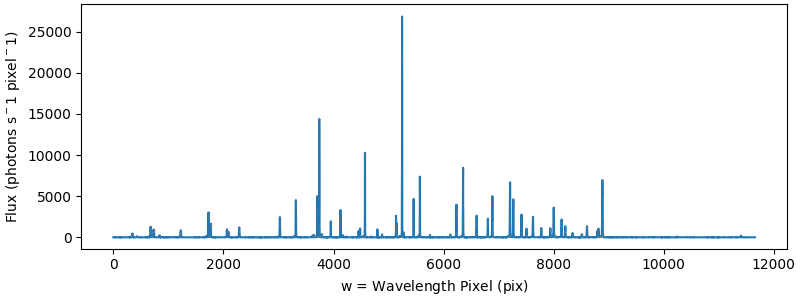

In [4]:
def plot_spectrum(spectrum, **kw):
    """
    Make a plot of a specutils.Spectrum object.

    Parameters
    ----------
    spectrum : specutils.Spectrum
        The main input should be a spectrum stored
        as a `specutils` object, with `.spectral_axis`
        and `.flux` attributes attached.
    **kw : dict
        All other keywords will be passed into the
        `plt.step` plotting function.
    """

    # extract the arrays we need
    x = spectrum.spectral_axis
    flux = spectrum.flux
    uncertainty = spectrum.uncertainty.quantity

    # plot the spectrum
    plt.step(x, flux, where="mid", **kw)
    plt.errorbar(
        x, flux, uncertainty, linewidth=0, elinewidth=1, color="gray", alpha=0.5
    )

    # add some labels
    if x.unit.is_equivalent(u.pixel):
        plt.xlabel(f'w = Wavelength Pixel ({x.unit.to_string(format="latex_inline")})')
    elif x.unit.is_equivalent(u.Angstrom):
        plt.xlabel(f'$\lambda$ = Wavelength ({x.unit.to_string(format="latex_inline")})')

    plt.ylabel("Flux (photons s$^-1$ pixel$^-1$)")


# test the plot
fi = plt.figure(figsize=(8, 3), constrained_layout=True)
fi.canvas.toolbar_position = "bottom"
plot_spectrum(spectrum)

## Subtract Any Continuum Flux 

In this particular spectrum, it was dark when we took the wavelength calibration emission lamp exposure, so there's not much continuum between the emission lines. However, if it was bright in the dome or you taking calibrations while also looking at the daytime sky, there might be smooth scattered light throughout filling in the gaps between the lines. We can subtract that off with a simple continuum fit, where we use a median filter of the spectrum to remove the emission lines, and then fit a smooth polynomial to the background level. It won't have much effect here, but we'll do it anyway to show how it works.

In [5]:
# fit a continuum function, using a median to skip over 
continuum_function = fit_generic_continuum(spectrum, median_window=201)
continuum_function

<QuantityModel Chebyshev1D(3, c0=4.46484286, c1=-0.00164738, c2=0.00000055, c3=-0.), input_units=pix, return_units=ph / (pix s)>

That continuum fit returns an `astropy.modeling.Model` object. In this case, it's just a polynomial, with coefficients fitted to best match our observed data (after trying to mask out the emission lines with a median filter). To get array values for the continuum, we simply call that `Model` object like a function:

In [6]:
# define a pixel axis, estimate continuum at those pixels
w = spectrum.spectral_axis
continuum = continuum_function(w)
continuum

<Quantity [ 4.46484231,  4.46319603,  4.46155197, ..., -6.6616081 ,
           -6.67408791, -6.68657179] ph / (pix s)>

We can make a continuum-subtracted spectrum by simply subtracting that flux array from our original spectrum (assuming everything's in the same units).

In [7]:
continuum_subtracted_spectrum = spectrum - continuum 

Let's plot those arrays to see how everything compares.

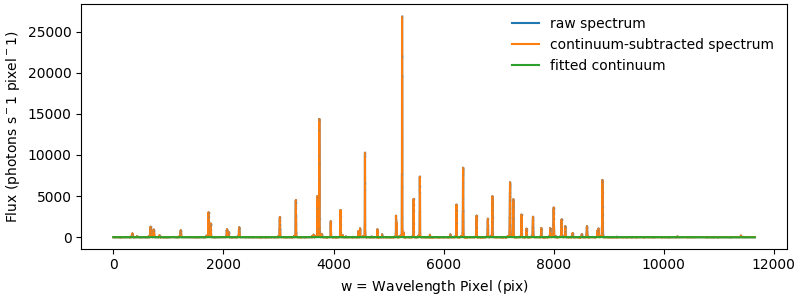

In [8]:

# plot the 
fi = plt.figure(figsize=(8, 3), constrained_layout=True)
fi.canvas.toolbar_position = "bottom"
plot_spectrum(spectrum, label='raw spectrum')
plot_spectrum(continuum_subtracted_spectrum, label='continuum-subtracted spectrum')
plt.plot(w, continuum_function(w), label='fitted continuum')
plt.legend(frameon=False); 

Great! It's a good thing the continuum is pretty close to zero for our spectrum, since by eye we could tell there wasn't much flux between the lines. If we zoom in, like down to `plt.ylim(-50,50)`, we can see some differences between the spectra. Quantitatively, continuum subraction doesn't matter with these example data, but it might matter for your data!

## Fit Lots of Lines

To fit a wavelength calibration, we're going to need to estimate the centroids of as many emission lines as possible. Fortunately, `specutils` has some handy tools for [finding emission lines](https://specutils.readthedocs.io/en/stable/fitting.html#line-finding); here we'll use `find_lines_derivative` to identify peaks from zero-crossings in the derivative, for lines with peaks above some flux threshold.

In [9]:
from specutils.fitting import find_lines_derivative

# generate intital guesses for the positions of many lines
lots_of_lines = find_lines_derivative(
    continuum_subtracted_spectrum, flux_threshold=50 * u.photon / u.s / u.pixel
)
lots_of_lines

line_center,line_type,line_center_index
pix,,
float64,str8,int64
337.0,emission,337
346.0,emission,346
430.0,emission,430
434.0,emission,434
640.0,emission,640
676.0,emission,676
680.0,emission,680
696.0,emission,696


Let's plot those rough line guesses over our spectrum to see if they make sense. 

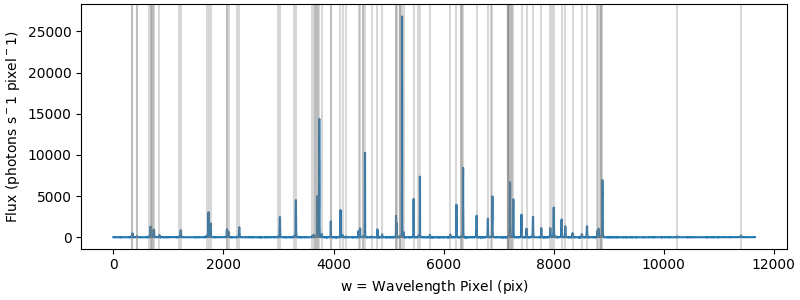

In [10]:
fi = plt.figure(figsize=(8, 3), constrained_layout=True)
fi.canvas.toolbar_position = "bottom"
plot_spectrum(continuum_subtracted_spectrum)
for l in lots_of_lines['line_center']:
    plt.axvline(l, color='gray', alpha=0.3)

Indeed, it looks like most of the detected lines align more or less with peaks in the spectrum, especially if we zoom in! Now that we have initial guesses, we can loop through each line and refine our estimates of the line centers from these rough integer values to more precise centroids. 

In [11]:
# how wide around each line guess should consider for a centroid?
line_centroiding_window = 10 * u.pixel

# create some empty columns in the table of lines
lots_of_lines["pixel"] = np.nan * u.pixel
lots_of_lines["fwhm"] = np.nan * u.pixel
lots_of_lines["flux"] = np.nan * u.photon / u.s
lots_of_lines["peak"] = np.nan * u.photon / u.s / u.pixel

# loop through lines, find centroids for each
for i in range(len(lots_of_lines)):

    # start from an initial guess
    line_guess = lots_of_lines["line_center"][i]

    # extract a region around the line
    sub_region = SpectralRegion(
        line_guess - line_centroiding_window, line_guess + line_centroiding_window
    )
    sub_spectrum = extract_region(continuum_subtracted_spectrum, sub_region)

    # extract some line diagnostics (which won't be perfect for blended lines)
    this_pixel = centroid(sub_spectrum)
    this_fwhm = fwhm(sub_spectrum)
    this_flux = line_flux(sub_spectrum)
    this_peak = np.max(sub_spectrum.flux)

    # store them in the table
    lots_of_lines["pixel"][i] = this_pixel
    lots_of_lines["fwhm"][i] = this_fwhm
    lots_of_lines["flux"][i] = this_flux
    lots_of_lines["peak"][i] = this_peak

# smoosh together lines that are too close to each other
too_close_to_others = np.zeros(len(lots_of_lines)).astype(bool)
for i in range(len(lots_of_lines)):
    this_pixel = lots_of_lines["pixel"][i]
    this_flux = lots_of_lines["flux"][i]
    is_nearby_to_this_line = (
        np.abs(lots_of_lines["pixel"] - this_pixel) <= line_centroiding_window * 2
    )

    if sum(is_nearby_to_this_line) > 1:
        is_fainter_than_this_line = lots_of_lines["flux"] < this_flux
        too_close_to_others += is_nearby_to_this_line * is_fainter_than_this_line
row_numbers_to_remove = np.nonzero(too_close_to_others)[0]
lots_of_lines.remove_rows(row_numbers_to_remove)

lots_of_lines

line_center,line_type,line_center_index,pixel,fwhm,flux,peak
pix,,,pix,pix,ph / s,ph / (pix s)
float64,str8,int64,float64,float64,float64,float64
346.0,emission,346,343.84189539943617,14.269149845102788,5845.729556437293,442.32426838587145
434.0,emission,434,433.31091786258185,12.001266999199288,1206.546623005047,108.56683270258694
640.0,emission,640,639.6370612526812,3.68268528307226,539.2389428101449,111.07134849687453
676.0,emission,676,676.6999450068796,14.132593565307843,17270.328310969235,1269.51265525973
733.0,emission,733,733.2661877787543,14.011349948262705,12631.008899177396,933.8329596876702
835.0,emission,835,837.4982197391555,12.527043793607504,2436.185036654615,201.54263076381395
1187.0,emission,1187,1187.386396392685,3.9941411337113095,337.90204249980326,69.22972461603084
1224.0,emission,1224,1223.808460762224,13.26733354842736,10780.063630346793,850.7143168402445


Great! That constructed a table of centroided pixel locations for lots of lines in our wavelength calibration exposure. We can see that the precise, measured, centroided  `pixel` positions are pretty close to, but slightly different than, the initial `line_center` guesses for the line positions estimated from `find_lines_derivative`. More precise pixel locations for the lines will translate into more precise wavelength calibration. But it's a little hard to just look at the table, so lets plot the spectrum, the initial guesses, and the measured centroids.

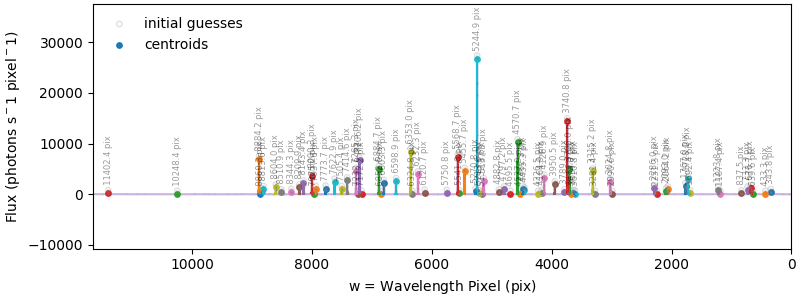

In [12]:
def plot_pixels(color=None):
    # plot the individual sub-spectra
    for i in range(len(lots_of_lines)):
        # start from an initial guess
        this_pixel = lots_of_lines["pixel"][i]
        this_peak = lots_of_lines["peak"][i]
        this_guess = lots_of_lines["line_center"][i]

        # extract a region around the line
        sub_region = SpectralRegion(
            this_pixel - line_centroiding_window, this_pixel + line_centroiding_window
        )
        sub_spectrum = extract_region(continuum_subtracted_spectrum, sub_region)

        # plot each sub-spectrum + line guess + measured centroid
        plot_spectrum(sub_spectrum, color=color)
        if i == 0:
            label = "initial guesses"
        else:
            label = None
        # plt.axvline(this_pixel, ymin=0.9, alpha=0.5, linestyle='--', color='gray', label=label)
        offset = 600
        guess_kw = dict(color="gray", alpha=0.25)
        s = 15
        plt.scatter(
            this_guess,
            this_peak.value + offset,
            label=label,
            marker="o",
            facecolor="none",
            s=s,
            **guess_kw,
        )
        plt.plot(
            u.Quantity([this_pixel, this_guess]),
            offset * np.arange(2) + this_peak.value,
            **guess_kw,
        )
        plt.text(
            this_pixel,
            offset + this_peak.value,
            f"  {this_pixel:.1f}",
            rotation=90,
            fontsize=6,
            ha="center",
            va="bottom",
            alpha=0.4,
        )
        if i == 0:
            label = "centroids"
        else:
            label = None
        plt.scatter(this_pixel, this_peak, label=label, s=s, color=color)

    # plot the full spectrum behind, for reference
    plot_spectrum(continuum_subtracted_spectrum, alpha=0.5, zorder=-100)
    plt.legend(frameon=False, loc='upper left')
    plt.xlim(len(uncalibrated), 0)
    buffer = np.max(spectrum.flux) * 0.4
    plt.ylim(-buffer, np.max(spectrum.flux) + buffer)


fi = plt.figure(figsize=(8, 3), constrained_layout=True)
fi.canvas.toolbar_position = "bottom"
plot_pixels()

Notice that we flipped the x-axis limits, to put larger pixels on the left. For the SBO spectrograph, smaller pixel values correspond to redder wavelengths, so it maybe easier to compare with a reference spectrum. Take a moment to zoom in on a few lines on the above plot. Check that you're finding lots of lines, and check that the centroid positions for those lines seem to make sense. To my eye, most of the centroids are pretty close to the initial guesses, but frequently with small tweaks that better match my sense of where the center of the line lies. Not all lines are perfect, and that's OK!

## Visually Match a Few Lines Between Pixel and Wavelength


To start our wavelength calibration, we need to associate some of these lines with wavelengths. We'll start with just a few line matches, and then try to use an initial fit to these to guess the matches for the remaining lines. This is an annoying part of trying to do some tricky manual pattern matching to figure out which lines are which. 

I did this by flipping back and forth through Autumn's [SBO wavelength references](https://github.com/zkbt/astr3520-handbook/tree/main/data/sbo/wavelength-references), looking for patterns of strong and weak lines next to each other, testing out hypotheses and iterating a few times on them. I checked whether the axes might be flipped relative to each other; it took a slightly annoying amount of fussing! Taking pixel locations from the measured centroids and wavelengths from the reference images, I came up with the following list of matched pixel-wavelength pairs: 

In [13]:
# construct a dictionary with a few initial wavelength matches
pixel_to_wavelength = {
    11402.4 * u.pixel: 5015.7 * u.AA,
    8884.2 * u.pixel: 5852.5 * u.AA,
    3740.8 * u.pixel: 7503.9 * u.AA,
    3024.8 * u.pixel: 7724.0 * u.AA,
    2286.0 * u.pixel: 7948.2 * u.AA,
    676.7 * u.pixel: 8424.6 * u.AA,
}

initial_pixels = u.Quantity(list(pixel_to_wavelength.keys()))
initial_wavelengths = u.Quantity(list(pixel_to_wavelength.values()))

To visualize these matches (= pixel in our observed spectrum, matched to our guess of what wavelength it represents), let's plot them underneath the spectrum in a different color. Notice that we tried to find matches that span as much of the detector as possible, so we don't need to count on using a function to extrapolate much beyond actual measurements.

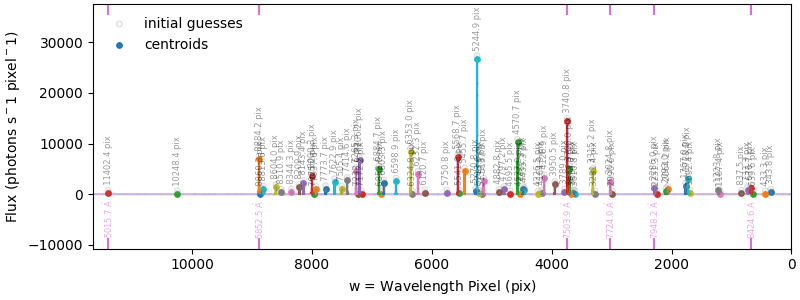

In [14]:
def plot_matches(pixels, wavelengths, color="orchid", **kw):
    '''
    Plot matched wavelengths onto a pixel grid.

    Parameters 
    ----------
    pixels : u.Quantity
        An array of pixel locations for known wavelengths. 
    wavelengths : u.Quantity
        An array of wavelengths, associated with each pixel location 
    color : str 
        The color with which to plot the wavelengths 
    **kw : dict 
        All other keywords will be passed to plt.axvline
    '''
    for p, w in zip(pixels, wavelengths):
        plt.axvline(p, ymin=0.96, ymax=1, color=color, **kw)
        plt.axvline(p, ymin=0, ymax=0.04, color=color, **kw)
        plt.text(
            p,
            0,
            w.to_string(format="latex_inline", formatter=".1f") + "   ",
            ha="center",
            va="top",
            rotation=90,
            fontsize=6,
            alpha=0.6,
            color=color,
        )

fi = plt.figure(figsize=(8, 3), constrained_layout=True)
fi.canvas.toolbar_position = "bottom"
plot_pixels()
plot_matches(initial_pixels, initial_wavelengths)

Here we've matched 6 pixel-wavelength pairs. Let's start by fitting an initial wavelength calibration to just those points. We'll use this as a coarse estimate of what the wavelength calibration might be, and refine it later. The default fit we'll do here is degree 3, meaning there are 4 coefficients that need to be fit, so it's good we have at least one more data point than coefficient we need to infer. We'll write up functions to fit a wavelength calibration to a set of pixel-wavelength pairs and to visualize this function, because we'll want to use them a few times below.

In [15]:
def fit_wavelength_calibration(pixels, wavelengths, degree=3):
    '''
    Estimate a wavelength calibration function from matched 
    pixel-to-wavelength pairs. 

    (Note, for conceptual simplicity, we're using a pixel 
    coordinate system that is 0 at one edge of the detector.
    From a numerical precision perspective, it would be 
    a bit better to redfine a pixel grid set to be 0 
    at the center of the detector. Doing so would remove
    the strongest degeneracies in the polynomial fitting
    problem and allow higher-degree fits before hitting 
    the round-off error limit of floating-point precision.
    That might look something like `x=pixels - x0` where 
    `x0 = len(spectrum.spectral_axis)/2`. Feel free to 
    play with that, but make sure you propagate it through 
    every place the polynomial model is being used!)

    Parameters 
    ----------
    pixels : u.Quantity
        An array of pixel locations.
    wavelengths : u.Quantity
        An array of wavelengths, associated with each pixel location. 
    degree : int 
        The polynomial degree to fit. 
    
    Returns 
    ------- 
    wavelength_calibration : astropy.modeling.Polynomial1D
        A fitted polynomial model that takes pixel as 
        input and returns wavelength as output. This astropy 
        model object is callable as a function, as in 
        `wavelength_calibration(pixels)` and also stores 
        details of the fit in attributes such as an array of
        polynomial coefficients `wavelength_calibration.parameters`
        or the individual parameters `wavelength_calibration.c0`, 
        `wavelength_calibration.c1`, etc... 
    '''
    # use astropy fitting to define a polynomial model
    fit = fitting.TRFLSQFitter()
    poly = models.Polynomial1D(degree=degree)
    # (annoyingling, domain= and window= don't seem to work with astropy units)

    # fit the polynomial to the pixel-wavelength pairs
    wavelength_calibration = fit(model=poly, x=pixels, y=wavelengths)

    # return the fitted model, which is callable as a function
    return wavelength_calibration

In [16]:
def plot_wavelength_calibration(wavelength_calibration, pixels, wavelengths):
    '''
    Plot a wavelength calibration function, 
    along with pixel-wavelength matches.

    This produces a three-panel plot. 

    Parameters 
    ----------
    wavelength_calibration : astropy.modeling.Polynomial1D
        A wavelength calibration function, likely returned 
        at some point from `fit_wavelength_calibration`.
    pixels : u.Quantity
        An array of pixel locations.
    wavelengths : u.Quantity
        An array of wavelengths, associated with each pixel location. 
    '''

    fi, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True, constrained_layout=True)
    fi.canvas.toolbar_position = "bottom"
    smooth_pixel_grid = np.linspace(
        np.min(spectrum.spectral_axis), np.max(spectrum.spectral_axis)
    )

    # plot raw emission line spectrum
    plt.sca(ax[0])
    plot_pixels()
    plt.xlabel('')
    plot_matches(pixels, wavelengths)

    # plot wavelength vs pixel
    plt.sca(ax[1])
    plt.ylabel(
        f'$\sf \lambda = $ Wavelength ({wavelengths.unit.to_string(format="latex_inline")})'
    )

    def stringify_equation(poly):
        x = "w"
        y = "$\lambda(w)$"
        terms = [
            f"$\sf {{{name}}}\cdot{{{x}}}^{{{power}}}$"
            for power, name in enumerate(poly.param_names)
        ]
        lhs = "+".join(terms)
        equation = f"{y} = {lhs}\n"
        for power in range(poly.degree + 1):
            coefficient = getattr(poly, f'c{power}')
            equation += f'  c{power} = {coefficient.value:.5g} {coefficient.unit.to_string(format="latex_inline")}\n'
        return equation

    plt.scatter(pixels, wavelengths)
    plt.plot(
        smooth_pixel_grid,
        initial_wavelength_calibration(smooth_pixel_grid),
        label=stringify_equation(wavelength_calibration),
    )
    legend_kw = dict(frameon=False, fontsize='small')
    plt.legend(**legend_kw)

    # plot the residuals (wavelength - model) vs pixel
    plt.sca(ax[2])
    residuals = wavelengths - wavelength_calibration(pixels)
    N = len(residuals)
    rms_wavelength = np.nanstd(residuals)

    # estimate derivative of polynomial to get rough pixel
    coeffs = wavelength_calibration.parameters[::-1]
    deriv_coeffs = np.polyder(coeffs)
    dwavelength_dpixel = np.mean(np.poly1d(deriv_coeffs)(smooth_pixel_grid.value))*wavelengths.unit/pixels.unit
    rms_pixel = np.abs(rms_wavelength/dwavelength_dpixel)
    plt.scatter(pixels, residuals)
    plt.ylabel(f'$\sf \lambda - \lambda(w)$ = Residuals ({residuals.unit.to_string(format="latex_inline")})')
    plt.axhspan(-rms_wavelength.value, rms_wavelength.value, alpha=0.3, label=rf"$\sigma$ = {rms_wavelength.to_string(format='latex_inline', formatter='.3g')} $\approx$ {rms_pixel.to_string(format='latex_inline', formatter='.3g')},"+f"\n{N} wavelength-pixel matches")
    plt.legend(**legend_kw)
    plt.ylim(-3*rms_wavelength, 3*rms_wavelength)
    plt.axhline()
    plt.xlabel(f'w = Wavelength Pixel ({pixels.unit.to_string(format="latex_inline")})')

OK, now that we have those functions defined, let's apply them to our initial manually-identified pixel-wavelength pairs. 

In [17]:
initial_wavelength_calibration = fit_wavelength_calibration(initial_pixels, initial_wavelengths)
initial_wavelength_calibration

<Polynomial1D(3, c0=8619.43200338 Angstrom, c1=-0.2854578 Angstrom / pix, c2=-0.00000378 Angstrom / pix2, c3=0. Angstrom / pix3)>

The returned wavelength calibration model can be treated just like a function. It takes pixel arrays as inputs and returns wavelengths. Let's try it with a simple little array of five pixels stretching across the detector:

In [18]:
a_few_pixels = np.arange(5)*2000*u.pixel
initial_wavelength_calibration(a_few_pixels)

<Quantity [8619.43200338, 8034.17582716, 7423.30862422, 6791.43558261,
           6143.16189036] Angstrom>

But for a better sense of what's going on, let's plot the wavelength calibration function, along with the data we used to infer it.

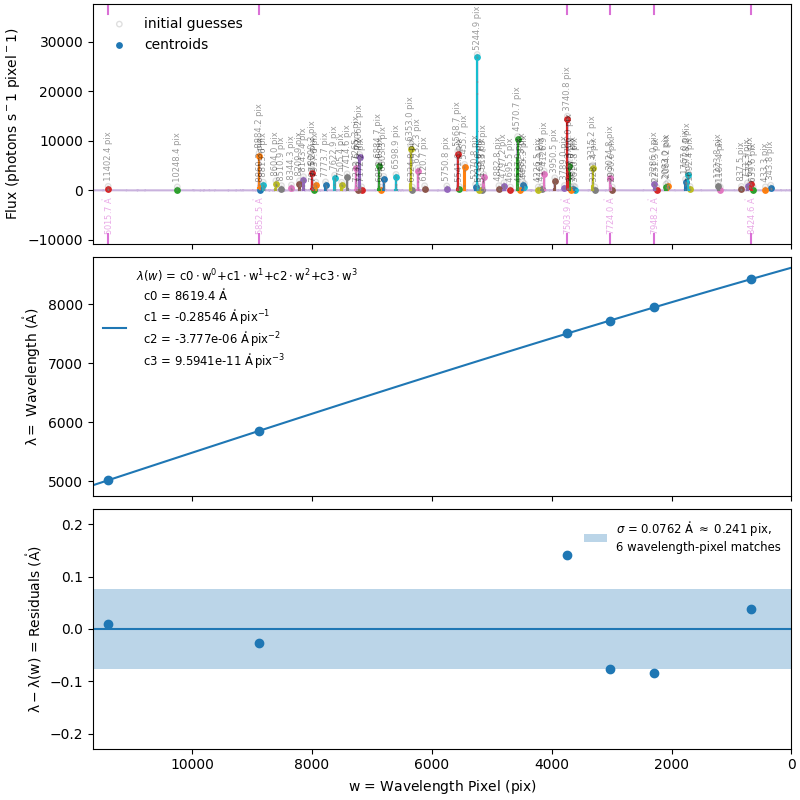

In [19]:
plot_wavelength_calibration(initial_wavelength_calibration, initial_pixels, initial_wavelengths)

Ooh, not bad! It looks like that's pretty good! With our polynomial, we're able to line up the 6 lines we identifed with a standard deviation that's better than a pixel! 

*But* with only a few points, there's a chance we might overfitting and not necessarily a guarantee this will work well over the entire detector. Since we actually observed so many lines, it'd be nice to be able to use more of them. To do that, without having to match them up manually one-by-one, let's load a list of lines and try to guess their pixel matches using our initial wavelength calibration. 

## Automatically Match Many Lines Between Pixel and Wavelength

First, let's load a list of wavelengths. These have no other information besides a wavelength that might be emitted by a particular lamp. We'll start with [the SBO reference list of wavelength calibration lines](data/HeNeAr-wavelengths-sbo.ecsv), but we could use other database too, if we prefer.

In [20]:
known_lines = QTable.read("data/HeNeAr-wavelengths-sbo.ecsv")
known_lines

wavelength,element
Angstrom,
float64,str4
5330.78,Ne
5341.09,Ne
5400.56,Ne
5748.3,Ne
5764.42,Ne
5804.45,Ne
5820.16,Ne
5852.49,Ne


For a visual reference, let's plot these lines. It might be a little hard to match up visually to our observed spectrum because we don't have the relative strengths, but it's a useful start at least!

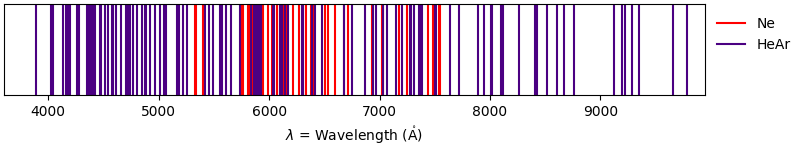

In [21]:
def plot_known_emission_lines(**kw):
    ''' 
    Plot emission lines on a wavelength axis. 

    '''
    colors = {"Ne": "red", "HeAr": "indigo"}
    needs_label = {k: True for k in colors}
    for i in range(len(known_lines)):
        wavelength = known_lines["wavelength"][i]
        element = known_lines["element"][i]
        if needs_label[element]:
            label = element
        else:
            label = None
        plt.axvline(wavelength, color=colors[element], label=label, **kw)
        needs_label[element] = False
    plt.legend(frameon=False, bbox_to_anchor=(1, 1))
    plt.xlabel(
        f'$\lambda$ = Wavelength ({known_lines["wavelength"].unit.to_string("latex_inline")})'
    )


# plot the reference wavelengths
fi = plt.figure(figsize=(8, 1.5), constrained_layout=True)
fi.canvas.toolbar_position = "bottom"
plot_known_emission_lines()
plt.yticks([]);


Now, let's use our initial wavelength calibration (the one inferred from just a few points) to guess the wavelengths of each of our measured pixel centroids. If there's at least one known wavelnegth close to that predicted location, we'll call it a match. We'll create a function to do this guessing, because we might want to iterate on it a few times. 

In [22]:
def guess_wavelength_matches(wavelength_calibration, unmatched_pixels, unmatched_wavelengths, wavelength_window = 5 * u.AA):
    ''' 
    Guess new pixel-wavelength matches from an 
    approximate initial wavelength calibration function. 

    Parameters 
    ----------
    wavelength_calibration : astropy.modeling.Polynomial1D
        A wavelength calibration function, likely returned 
        at some point from `fit_wavelength_calibration`.
    unmatched_pixels : u.Quantity
        An array of pixel locations corresponding to  
        the lines we identified in our own wavelength 
        calibration exposure. 
    unmatched_wavelengths : u.Quantity
        An array of wavelengths, which does not need to be 
        the same length nor associated at all yet with the 
        pixel locations. It could be a list of known 
        wavelengths for the particular emission lamp(s)
        being used.
    wavelength_window : u.Quantity
        The maximum difference (w - w_predicted) allowed 
        for a pair to still be called a match. Keeping 
        this fairly small helps prevents making wrong 
        matches accidentally, but you might need to 
        make it a little bigger if your initial 
        wavelength calibration isn't great. 
    '''

    # translate from pixels to predicted wavelengths
    guessed_wavelengths = wavelength_calibration(unmatched_pixels)

    # create empty lists of matched pixels
    automatic_pixels = []
    automatic_wavelengths = []

    # loop over the reference wavelengths
    for i in range(len(unmatched_wavelengths)):

        # find the closest measured line to this reference line
        distance_to_lines = np.abs(unmatched_wavelengths[i] - guessed_wavelengths)
        i_closest = np.argmin(distance_to_lines)

        # only include the line if it's less than some reasonably large threshold
        if distance_to_lines[i_closest] < wavelength_window:
            automatic_pixels.append(unmatched_pixels[i_closest])
            automatic_wavelengths.append(unmatched_wavelengths[i])

    # convert these lists into arrays
    automatic_pixels = u.Quantity(automatic_pixels)
    automatic_wavelengths = u.Quantity(automatic_wavelengths)

    return automatic_pixels, automatic_wavelengths

pixels, wavelengths = guess_wavelength_matches(initial_wavelength_calibration, lots_of_lines['pixel'], known_lines['wavelength'])

In [23]:
pixels

<Quantity [10248.4445732 ,  8884.15339312,  8813.58433496,  8604.04181367,
            8344.30621182,  8209.91493025,  8143.3782273 ,  8000.31882734,
            7937.64265009,  7773.71464614,  7622.94183406,  7505.43395728,
            7414.58082401,  7265.32790338,  7206.16152275,  6884.67522825,
            6803.29609937,  6598.90574621,  6352.98895411,  6232.27799293,
            5568.65219878,  5270.757812  ,  5244.9113487 ,  4797.24547384,
            4570.68546994,  3950.49137156,  3789.04990617,  3637.65069856,
            3610.758073  , 11402.4037385 ,  8860.26340713,  8813.58433496,
            8344.30621182,  8143.3782273 ,  8000.31882734,  7505.43395728,
            7265.32790338,  7172.16765953,  6352.98895411,  6120.67778856,
            5750.8319987 ,  5541.60721688,  5455.72032604,  5244.9113487 ,
            5137.28196602,  4882.7887953 ,  4695.46477126,  4482.26865356,
            4455.31000555,  4226.50891239,  4164.93966248,  4126.87359419,
            3740.83073753

In [24]:
wavelengths

<Quantity [5400.56, 5852.49, 5872.83, 5944.83, 6029.99, 6074.34, 6096.16,
           6143.06, 6163.59, 6217.28, 6266.5 , 6304.8 , 6334.43, 6382.99,
           6402.25, 6506.53, 6532.88, 6598.95, 6678.28, 6717.04, 6929.47,
           7024.05, 7032.41, 7173.94, 7245.17, 7438.9 , 7488.87, 7535.77,
           7544.04, 5015.68, 5860.31, 5875.62, 6032.13, 6098.8 , 6145.44,
           6307.66, 6384.72, 6416.3 , 6678.15, 6752.83, 6871.29, 6937.67,
           6965.43, 7030.25, 7065.19, 7147.04, 7206.98, 7272.94, 7281.35,
           7353.32, 7372.12, 7383.98, 7503.87, 7514.65, 7635.11, 7723.99,
           7948.18, 8006.16, 8014.79, 8103.69, 8115.31, 8264.52, 8408.21,
           8424.65, 8521.44] Angstrom>

Cool! This automated guess appears to find lots of potential pixel-wavelength matches. Let's see how the look plotted against the *initial* wavelength calibration (the one we inferred from just a few lines).

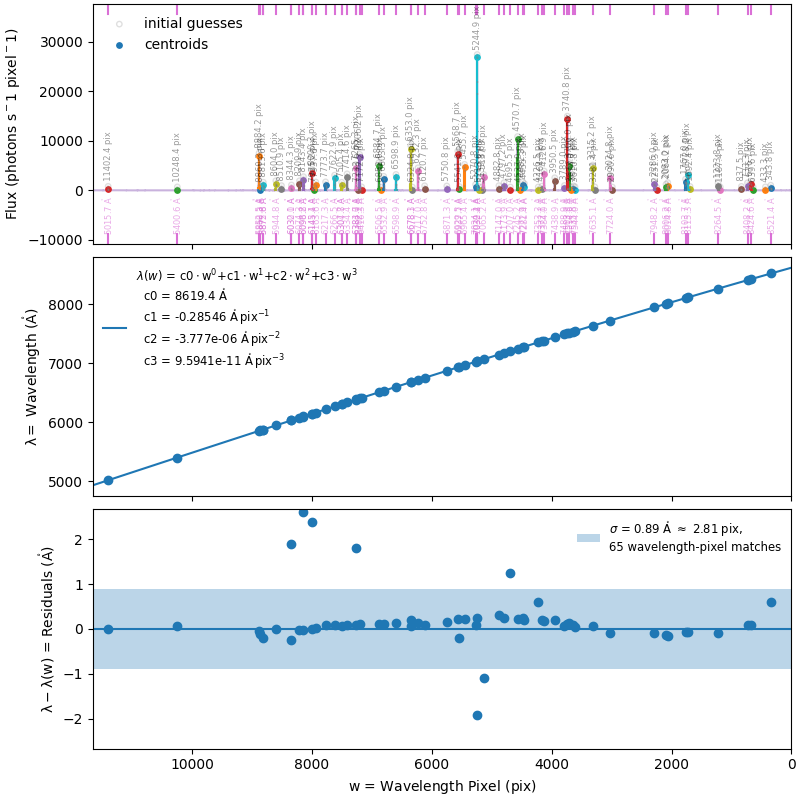

In [25]:
plot_wavelength_calibration(initial_wavelength_calibration, pixels, wavelengths)

Wow, not bad! There are lots of lines that all seem to line up pretty closely with predictions. We can tell there are few points that seem like fairly dramatic outliers; those are likely peaks that we matched to the wrong wavelength. To try to get an even better wavelength calibration, let's use this larger sample of emission lines to refit the wavelength calibration.

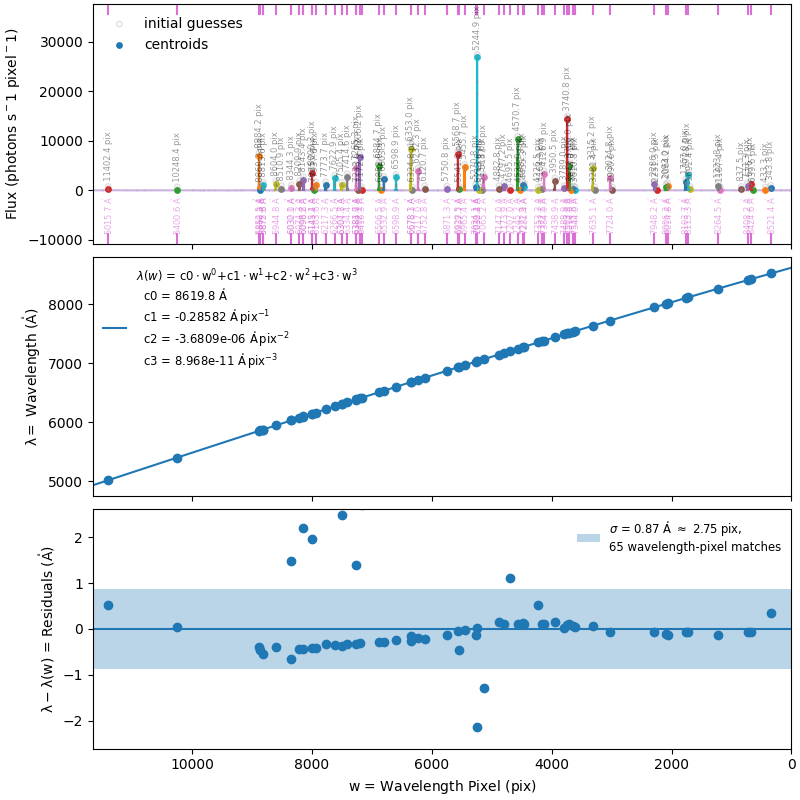

In [26]:
# fit the large sample of automatically matched lines
refined_wavelength_calibration = fit_wavelength_calibration(pixels, wavelengths, degree=3)
plot_wavelength_calibration(refined_wavelength_calibration, pixels, wavelengths)

The refit didn't do too much to improve the standard deviation of the residuals. But, now that we have a good fit that includes many lines, we can be more strict in which lines we identify as being matches. Let's redo our guess for the pixel to wavelength matches, but now define matches only if predicted and actual wavelengths fall within $\sf 1 \AA$ window, smaller than the default window we used above to remove the most egregious outliers.

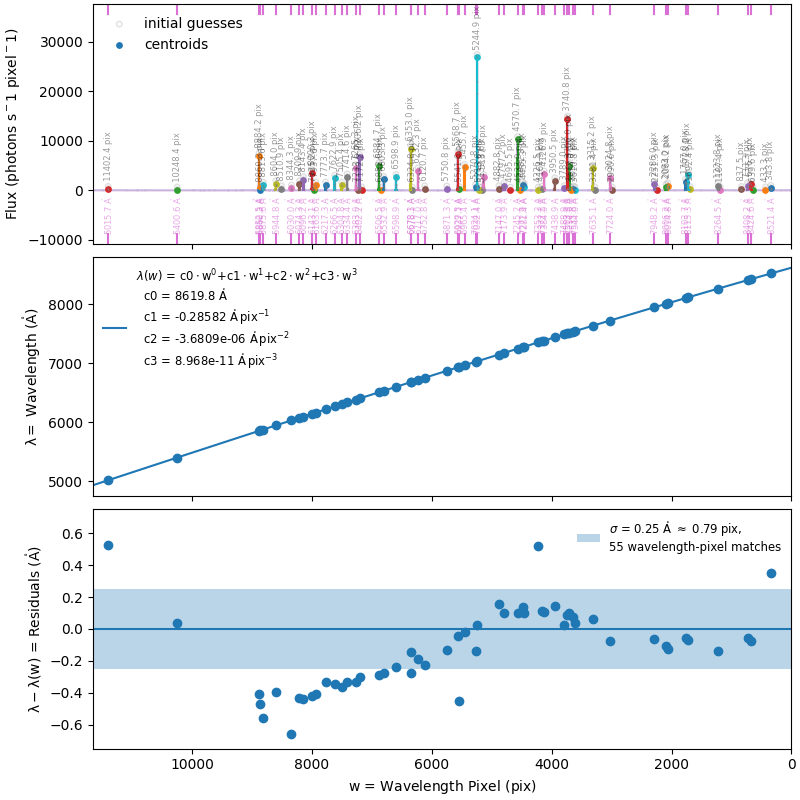

In [27]:
# place a stricter cut on what we call wavelength matches, then refit
pixels, wavelengths = guess_wavelength_matches(refined_wavelength_calibration, pixels, wavelengths, wavelength_window=1*u.AA)
plot_wavelength_calibration(refined_wavelength_calibration, pixels, wavelengths)

Now that we have a good set of pixel-to-wavelength pairs, let's explore how complicated of a polynomial we might want to use for our wavelength calibration. We want to have reasonable compromise between being complex enough (= enough wiggles to capture the shape the optics of the spectrograph) but not being so complex that we start over-fitting (= trying to fit too many parameters to too few data points), let's test a few different polynomial degrees and see how the fits look.

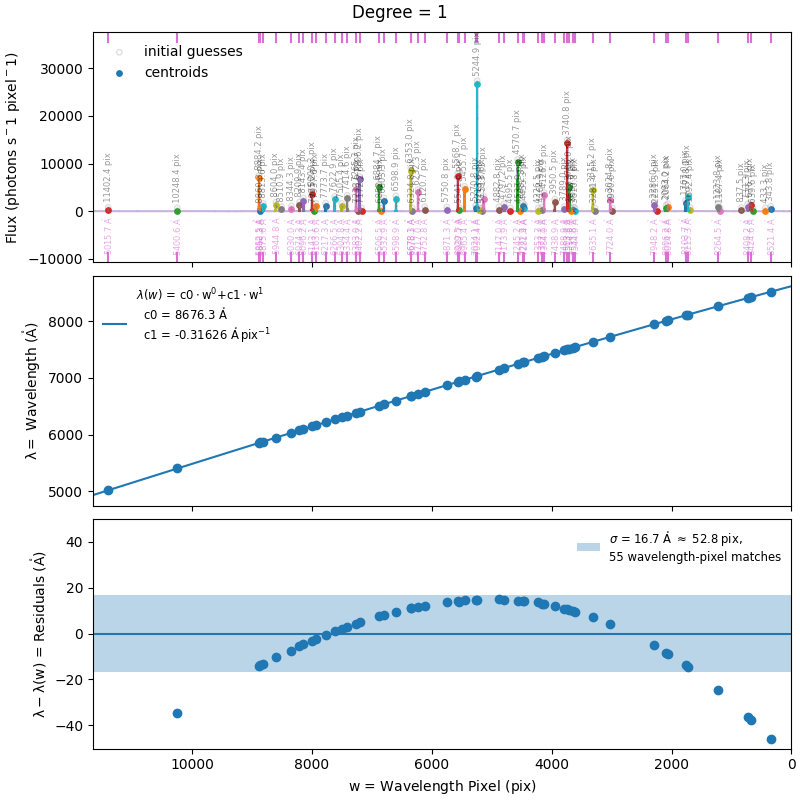

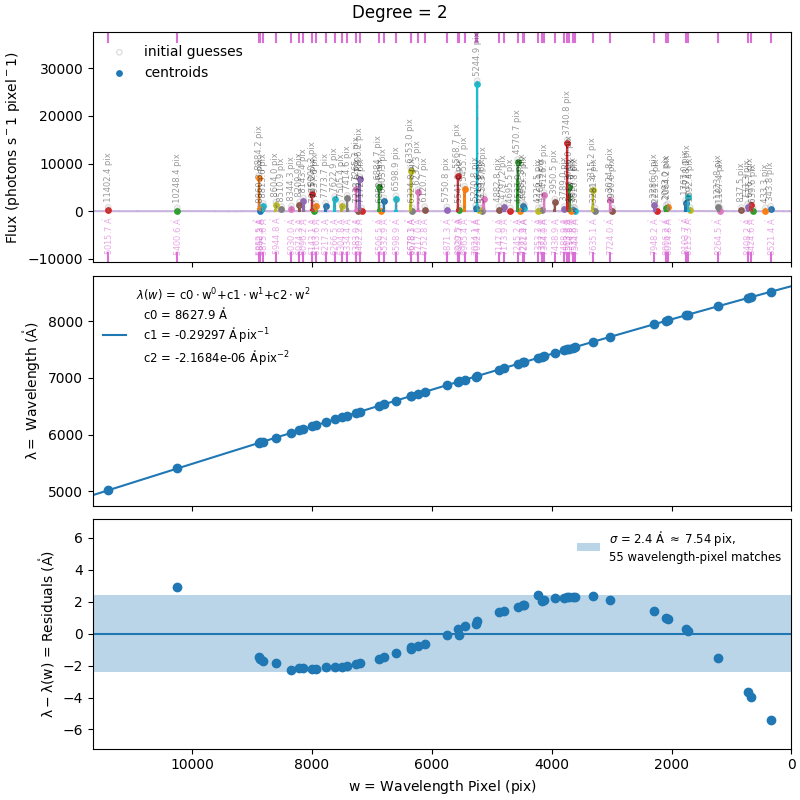

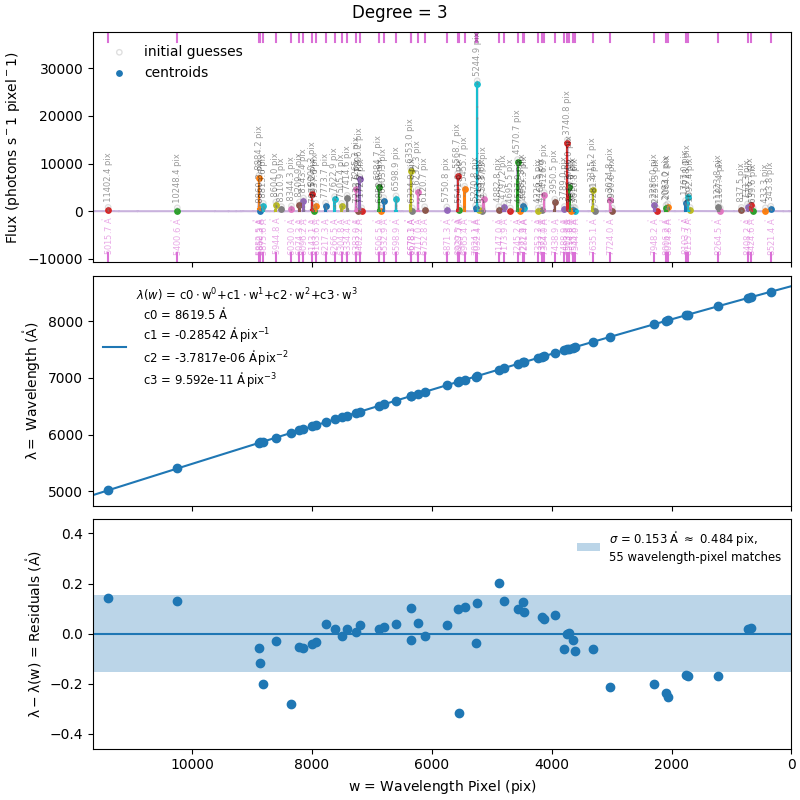

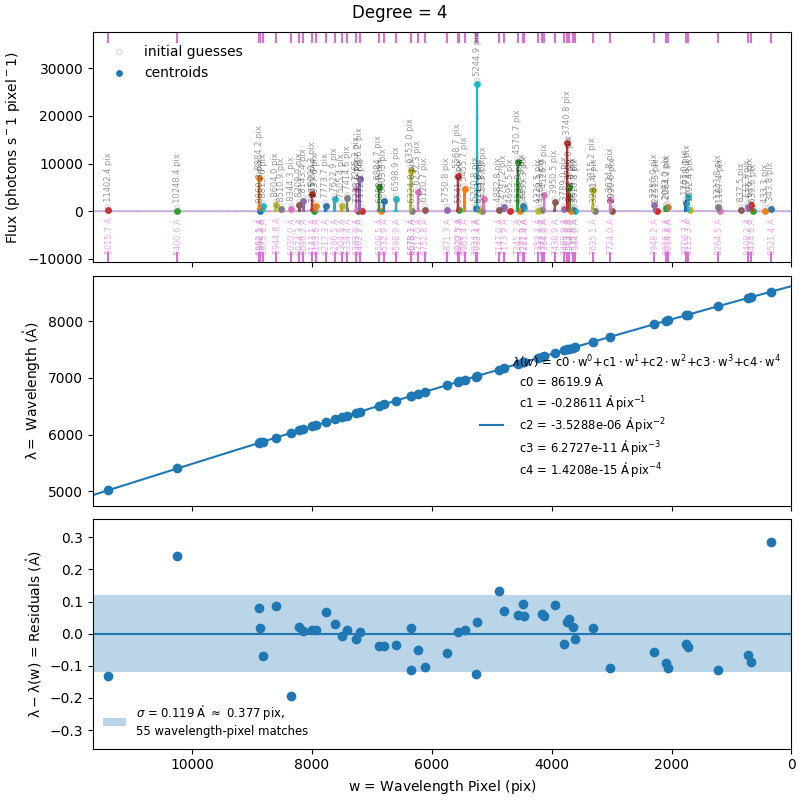

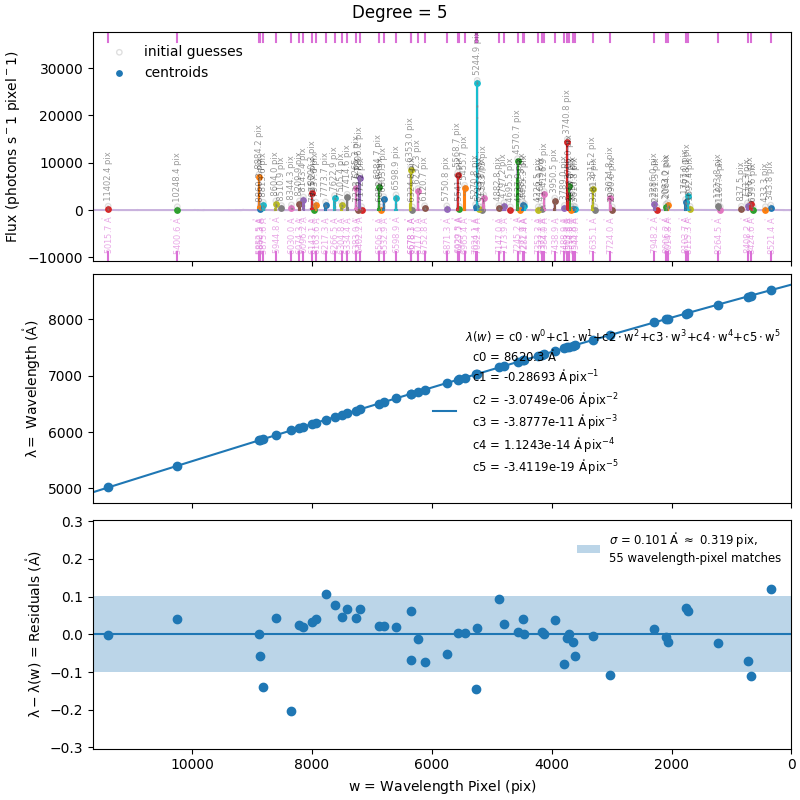

In [28]:
for degree in [1,2,3,4,5]:
    possible_wavelength_calibration = fit_wavelength_calibration(pixels, wavelengths, degree=degree)
    plot_wavelength_calibration(possible_wavelength_calibration, pixels, wavelengths)
    plt.suptitle(f'Degree = {degree}')

Wow, gosh! We can see the wavelength calibration improving as we add more polynomial terms. A linear (`degree=1`) and quadratic (`degree=2`) fit leave pretty obvious trends in the residuals. But once we get up to higher order polynomials (`degree=[3,4,5]`), we see the models can mostly work pretty well! They predict the positions of lines with a standard deviation of the residuals that's really small, less than half a pixel. You could argue about the benefits of the slightly simpler (`degree=3`) vs slightly more complex (`degree=5`) options, but for our sake here let's just take the compromise of `degree=4`. No matter what, given the optics of our charming old spectrograph, it's going to be very difficult to get to a wavelength calibration that's much better than a few tenths of a pixel precision.


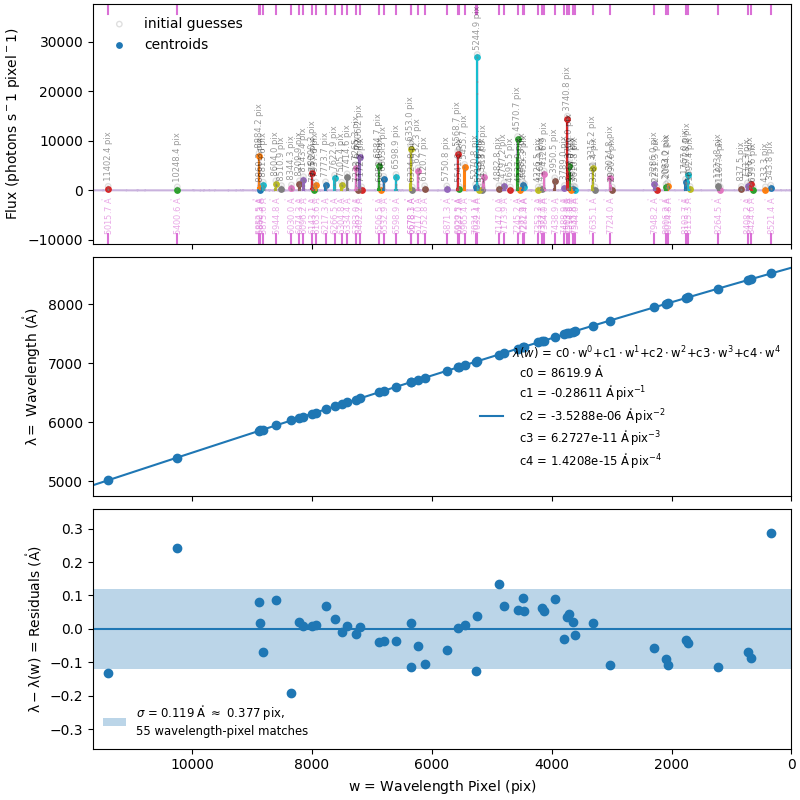

In [29]:
wavelength_calibration = fit_wavelength_calibration(pixels, wavelengths, degree=4)
plot_wavelength_calibration(wavelength_calibration, pixels, wavelengths)

## Apply Our Wavelength Calibration

Now that we have a function `wavelength_calibration` connecting pixels to wavelengths, we can calculate the wavelengths associated with each pixel in our spectrum!

In [30]:
w = uncalibrated["wavelength_pixel"]
wavelength = wavelength_calibration(w)
wavelength

<Quantity [8619.9453898 , 8619.65927575, 8619.37315465, ..., 4932.17334043,
           4931.83953413, 4931.50572748] Angstrom>

The wavelengths decrease toward increasing wavelength pixel, and they span roughly $\sf 8600-4900\AA$ for this grating angle. Let's make a `Spectrum` with these calibrated wavelengths instead of pixels as the `spectral_axis`. 

In [31]:
# create a specutils "Spectrum" object
calibrated_spectrum = Spectrum(
    spectral_axis=wavelength,
    flux=uncalibrated["flux"],
    uncertainty=StdDevUncertainty(uncalibrated["uncertainty"]),
)
calibrated_spectrum

<Spectrum(flux=[13.566 ... 7.182] ph / (pix s) (shape=(11656,), mean=94.90942 ph / (pix s)); spectral_axis=<SpectralAxis [8619.9453898  8619.65927575 8619.37315465 ... 4932.17334043 4931.83953413
 4931.50572748] Angstrom> (length=11656); uncertainty=StdDevUncertainty)>

Finally, let's plot that spectrum, with its wavelength calibration attached. Now, we should be able to overlap the database emission line wavelengths. If we've done our calibration correctly, they should line up with the peaks in our spectrum. 

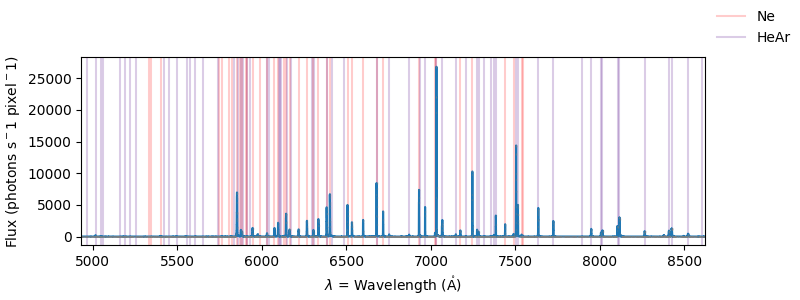

In [32]:
fi = plt.figure(figsize=(8, 3), constrained_layout=True)
fi.canvas.toolbar_position = "bottom"
plot_known_emission_lines(alpha=0.2)
plot_spectrum(calibrated_spectrum)
plt.xlim(min(wavelength), max(wavelength));

Oh, thank goodness! The wavelengths all seem to line up, even when we zoom in down to the weak lines in the blue. It works! Now, in addition to wavelength-calibrating our wavelength-calibration spectrum (which maybe isn't the most interesting thing in the world to do), we can apply this wavelength calibration function to *any other spectrum* taken with the same spectrograph settings as the calibration data. 

## Save a Calibrated Spectrum

Finally, let's write out a new file with a wavelength column added. We can go on to do neat science with our delightfully wavelength-calibrated spectra!

In [33]:
calibrated = QTable(uncalibrated)
calibrated['wavelength'] = wavelength 
calibrated

wavelength_pixel,flux,uncertainty,wavelength
pix,ph / (pix s),ph / (pix s),Angstrom
float64,float64,float64,float64
0.0,13.566,5.782850542768679,8619.945389797489
1.0,5.32,5.019498022711036,8619.659275751372
2.0,3.99,4.885218562152567,8619.373154648045
3.0,6.118,5.098368405676467,8619.087026487883
4.0,7.448,5.22717518359582,8618.800891271263
5.0,23.40800000000001,6.579009074321148,8618.514748998563
6.0,-1.596,4.275436866566971,8618.22859967016
7.0,10.374,5.499941854238098,8617.942443286427


In [34]:
calibrated.write('data/sbo/extracted-HeNeAr-wavelengths.ecsv', overwrite=True)

OK, good grief. To review, in this example we:
- loaded and continuum subtracted an emission line spectrum
- found centroids for all strong lines in that spectrum
- matched the pixel locations of few of those lines by eye to known wavelengths
- fit an initial wavelength calibration data to these by-eye matches
- used that initial fit to guess many more additional matches
- refined our wavelength calibration to exclude poorly matched outliers
- decided on how complicated of a wavelength calibration we wanted to use
- applied our final wavelength calibration to convert pixels to wavelength
Yowzers!